## **Medical Image Processing**


In [1]:
# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
from tqdm import tqdm
import cv2

In [3]:
# Directory that contains all the data/script
current_dir = "/content/drive/MyDrive/PROVA_FINALE"

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
from skimage.morphology import binary_opening, disk

# ============================================================
# PREPROCESSING (MACENKO)
# ============================================================
class Preprocessing:
    @staticmethod
    def normalize_stain_macenko(img_rgb_uint8, Io=240, alpha=1, beta=0.15):
        img_original = img_rgb_uint8.copy()

        HERef = np.array([[0.5626, 0.2159],
                          [0.7201, 0.8012],
                          [0.4062, 0.5581]])
        maxCRef = np.array([1.9705, 1.0308])

        h, w, c = img_rgb_uint8.shape
        img_flat = img_rgb_uint8.reshape((-1, 3))

        OD = -np.log((img_flat.astype(float) + 1) / Io)
        ODhat = OD[~np.any(OD < beta, axis=1)]

        if len(ODhat) < 10:
            return img_original

        eigvals, eigvecs = np.linalg.eigh(np.cov(ODhat.T))
        Vec = eigvecs[:, 1:3]
        That = np.dot(ODhat, Vec)

        phi = np.arctan2(That[:, 1], That[:, 0])
        minPhi = np.percentile(phi, alpha)
        maxPhi = np.percentile(phi, 100 - alpha)

        vMin = np.dot(Vec, [np.cos(minPhi), np.sin(minPhi)])
        vMax = np.dot(Vec, [np.cos(maxPhi), np.sin(maxPhi)])

        if vMin[0] > vMax[0]:
            HE = np.array([vMin, vMax])
        else:
            HE = np.array([vMax, vMin])

        HE = HE.T
        Y = OD.T
        C = np.linalg.lstsq(HE, Y, rcond=None)[0]

        maxC = np.percentile(C, 99, axis=1)
        scale = maxC / maxCRef
        scale[scale == 0] = 1e-5

        C2 = C / scale[:, None]
        Inorm = Io * np.exp(-np.dot(HERef, C2))
        Inorm[Inorm > 255] = 255
        Inorm = Inorm.T.reshape((h, w, 3)).astype(np.uint8)
        return Inorm

    @staticmethod
    def preprocess_cv2_bgr_to_tensor(img_bgr_uint8, input_size=None):
        """
        img_bgr_uint8: immagine letta con cv2.imread -> BGR uint8 (H,W,3)
        input_size: (H,W) oppure None
        ritorna: torch tensor (1,3,H,W) float32 in [0,1]
        """
        if img_bgr_uint8 is None:
            raise ValueError("Immagine None (cv2.imread ha fallito).")

        # BGR -> RGB (Macenko lavora in RGB)
        img_rgb = cv2.cvtColor(img_bgr_uint8, cv2.COLOR_BGR2RGB)

        # Macenko
        img_rgb = Preprocessing.normalize_stain_macenko(img_rgb)
        img_rgb = img_rgb[..., ::-1]  # swap R<->B

        # Resize eventuale
        if input_size is not None:
            H, W = int(input_size[0]), int(input_size[1])
            img_rgb = cv2.resize(img_rgb, (W, H), interpolation=cv2.INTER_LINEAR)

        # to tensor (1,3,H,W)
        x = (img_rgb.astype(np.float32) / 255.0)
        x = torch.from_numpy(x).permute(2, 0, 1).contiguous()
        return x.unsqueeze(0)



# ============================================================
# MODELLO 7A (UNet + SEBlock)
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, init_filters=64, depth=3):
        super().__init__()
        self.depth = depth
        self.pool = nn.MaxPool2d(2)

        self.down_layers = nn.ModuleList()
        self.up_layers   = nn.ModuleList()
        self.se_blocks   = nn.ModuleList()

        filters = init_filters

        # Encoder
        for _ in range(depth):
            conv = DoubleConv(in_channels, filters)
            self.down_layers.append(conv)
            self.se_blocks.append(SEBlock(filters))
            in_channels = filters
            filters *= 2

        # Bottleneck
        self.bottleneck = DoubleConv(in_channels, filters)

        # Decoder
        for _ in range(depth):
            up = nn.ConvTranspose2d(filters, filters // 2, kernel_size=2, stride=2)
            conv = DoubleConv(filters, filters // 2)  # dopo concat
            self.up_layers.append(nn.ModuleDict({"up": up, "conv": conv}))
            filters //= 2

        self.out_conv = nn.Conv2d(init_filters, out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.down_layers:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for i in range(self.depth):
            skip = skip_connections[-(i+1)]
            skip = self.se_blocks[-(i+1)](skip)

            up = self.up_layers[i]["up"](x)
            if up.size() != skip.size():
                up = F.interpolate(up, size=skip.shape[2:])

            x = torch.cat([skip, up], dim=1)
            x = self.up_layers[i]["conv"](x)

        return self.out_conv(x)


# ============================================================
# POST-PROCESSING: ONLY OPENING
# ============================================================
def postprocess_opening_only(pred_bin_uint8, opening_r=1):
    """
    pred_bin_uint8: mask binaria uint8 (0/1 oppure 0/255)
    return: uint8 0/1
    """
    m = (pred_bin_uint8 > 0)                  # bool
    m = binary_opening(m, disk(int(opening_r)))
    return m.astype(np.uint8)



**2. Load the configuration and weights of the trained U-Net model**

In [5]:
import json
import torch
import os

def load_model_from_checkpoint(checkpoint_dir, epoch_to_load):
    params_path = os.path.join(checkpoint_dir, "training_params.json")

    with open(params_path, "r") as f:
        params = json.load(f)

    print("Loaded parameters:", params)

    model = UNet(
        in_channels=params["in_channels"],
        out_channels=params["out_channels"],
        init_filters=params["init_filters"],
        depth=params["depth"]
    )

    checkpoint_path = os.path.join(checkpoint_dir, f"model_epoch_{epoch_to_load}.pth")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)

    model = model.to(device).eval()
    print(f"Checkpoint for epoch {epoch_to_load} loaded from {checkpoint_path}")

    # Parametri “fissi” per sola inferenza
    best_thr = float(params.get("best_threshold", 0.6))  # fallback
    min_area = int(params.get("min_area", 20))

    return model, params, best_thr, min_area


In [8]:
checkpoint_dir = os.path.join(current_dir, "epoch_and_parameters")
epoch_number = 16  # <-- EPOCA MIGLIORE

model, params, BEST_THRESHOLD, MIN_AREA = load_model_from_checkpoint(checkpoint_dir, epoch_number)

OPENING_R = 1

input_size = params.get("input_size", None)
if input_size is not None:
    input_size = (int(input_size[0]), int(input_size[1]))
print("BEST_THRESHOLD:", BEST_THRESHOLD, "| MIN_AREA:", MIN_AREA, "| input_size:", input_size)

Loaded parameters: {'in_channels': 3, 'out_channels': 1, 'init_filters': 64, 'depth': 3, 'input_size': None, 'best_threshold': 0.6, 'min_area': 20}
Checkpoint for epoch 16 loaded from /content/drive/MyDrive/PROVA_FINALE/epoch_and_parameters/model_epoch_16.pth
BEST_THRESHOLD: 0.6 | MIN_AREA: 20 | input_size: None


**3. Apply trained model to the test set**




In [9]:
from tqdm import tqdm
import numpy as np
import os
import torch
import cv2

# Define paths
test_images_dir  = os.path.join(current_dir, "dataset_diviso_PROCESSED", "TS", "image")      # <-- immagini in input
output_masks_dir = os.path.join(current_dir, "TEST_PRED")      # <-- cartella predizioni in output

os.makedirs(output_masks_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# Lista file immagine
image_files = [f for f in os.listdir(test_images_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
image_files = sorted(image_files)

@torch.inference_mode()
def infer_one_bgr(img_bgr_uint8):
    # preprocess (Macenko + eventuale resize coerente con params)
    x = Preprocessing.preprocess_cv2_bgr_to_tensor(img_bgr_uint8, input_size=input_size).to(device)

    # forward
    if device.type == "cuda":
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(x)
            prob = torch.sigmoid(logits)[0, 0].float().cpu().numpy()
    else:
        logits = model(x)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()

    # binarizzazione con soglia fissa (quella trovata da voi sul VS)
    pred = (prob > float(BEST_THRESHOLD)).astype(np.uint8)

    # post-processing: only opening
    pred = postprocess_opening_only(pred, opening_r=OPENING_R)


    return pred  # {0,1}

for img_name in tqdm(image_files, desc="Inference on test set"):
    img_path = os.path.join(test_images_dir, img_name)

    img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)  # BGR uint8
    if img_bgr is None:
        raise FileNotFoundError(f"Impossibile leggere: {img_path}")

    pred_bin = infer_one_bgr(img_bgr)

    # Salvataggio maschera finale 0/255 (single-channel)
    pred_mask_uint8 = (pred_bin * 255).astype(np.uint8)
    cv2.imwrite(os.path.join(output_masks_dir, img_name), pred_mask_uint8)


Inference on test set: 100%|██████████| 56/56 [01:11<00:00,  1.28s/it]


**3. Calcolo delle metriche**

In [10]:
import os
import numpy as np
from PIL import Image
from skimage import measure
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm
import matplotlib.pyplot as plt

In [11]:
def calculate_challenge_metrics(manual_mask, auto_mask):

    manual_mask = np.array(manual_mask) > 0
    auto_mask   = np.array(auto_mask) > 0

    TP = np.sum(manual_mask & auto_mask)
    FP = np.sum((~manual_mask) & auto_mask)
    FN = np.sum(manual_mask & (~auto_mask))
    TN = np.sum((~manual_mask) & (~auto_mask))

    # ===== IoU =====
    union = TP + FP + FN
    IoU = TP / union if union > 0 else np.nan

    # ===== Dice =====
    denom_dice = 2*TP + FP + FN
    Dice = 2*TP / denom_dice if denom_dice > 0 else np.nan

    # ===== Precision =====
    Precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan

    # ===== Recall =====
    Recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan

    # ===== Accuracy =====
    Accuracy = (TP + TN) / (TP + TN + FP + FN)

    # ===== Count Error =====
    labels_man = measure.label(manual_mask, connectivity=2)
    labels_auto = measure.label(auto_mask, connectivity=2)
    count_error = abs(labels_man.max() - labels_auto.max())

    # ===== Steatosis Error =====
    area = manual_mask.size
    sp_manual = manual_mask.sum() / area * 100
    sp_auto   = auto_mask.sum() / area * 100
    steatosis_error = abs(sp_manual - sp_auto)

    # ===== Hausdorff =====
    coords_man  = np.column_stack(np.nonzero(manual_mask))
    coords_auto = np.column_stack(np.nonzero(auto_mask))

    if coords_man.size > 0 and coords_auto.size > 0:
        hd1 = directed_hausdorff(coords_man, coords_auto)[0]
        hd2 = directed_hausdorff(coords_auto, coords_man)[0]
        HD = max(hd1, hd2)
    else:
        HD = np.nan

    return IoU, Dice, Precision, Recall, Accuracy, HD, count_error, steatosis_error


Inizio valutazione su 56 immagini...


100%|██████████| 56/56 [00:17<00:00,  3.23it/s]



Risultati (Mean ± Std) + NaN count
IoU            : 0.5001 ± 0.2203   | NaN: 20/56
Dice           : 0.6334 ± 0.2298   | NaN: 20/56
Precision      : 0.6806 ± 0.2472   | NaN: 20/56
Recall         : 0.6607 ± 0.2177   | NaN: 21/56
Accuracy       : 0.9917 ± 0.0123   | NaN: 0/56
HD             : 103.6340 ± 83.9425   | NaN: 21/56
CountError     : 4.0000 ± 5.8095   | NaN: 0/56
SteatosisError : 0.2267 ± 0.3320   | NaN: 0/56

Distribuzione casi (GT vs Pred)
empty_empty       : 20 (35.7%)
gt_empty_pred_pos : 1 (1.8%)
gt_pos_pred_empty : 0 (0.0%)
pos_pos           : 35 (62.5%)

Micro-averaged (global TP/FP/FN/TN)
IoU_micro       : 0.6731
Dice_micro      : 0.8046
Precision_micro : 0.8322
Recall_micro    : 0.7789
Accuracy_micro  : 0.9917


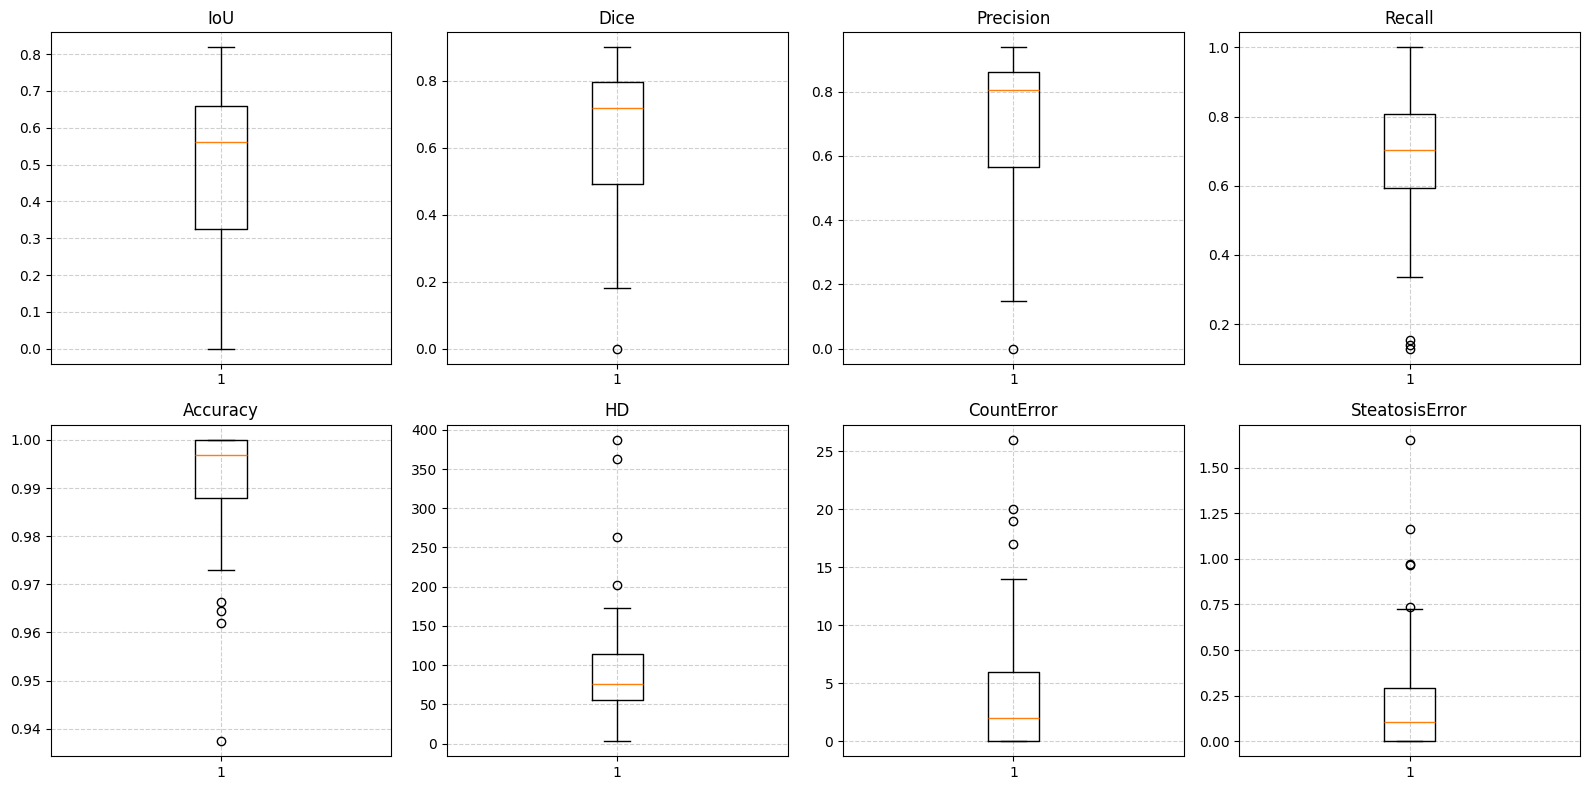

In [14]:
# Configurazione
path_mask_manual = os.path.join(current_dir,'dataset_diviso_PROCESSED', 'TS', 'manual')
path_mask_auto   = os.path.join(current_dir, 'TEST_PRED')

filenames = sorted([f for f in os.listdir(path_mask_manual) if f.endswith('.png')])

metrics_dict = {
    "IoU": [], "Dice": [], "Precision": [], "Recall": [], "Accuracy": [],
    "HD": [], "CountError": [], "SteatosisError": []
}

print(f"Inizio valutazione su {len(filenames)} immagini...")

# EXTRA: conteggi casi + conteggio NaN + micro-averaging
case_counts = {"empty_empty": 0, "gt_empty_pred_pos": 0, "gt_pos_pred_empty": 0, "pos_pos": 0}
nan_counts  = {k: 0 for k in metrics_dict.keys()}
TP_g = FP_g = FN_g = TN_g = 0

for f_name in tqdm(filenames):
    path_man = os.path.join(path_mask_manual, f_name)

    path_aut = os.path.join(path_mask_auto, f_name)

    if not os.path.exists(path_aut):
        print(f"Attenzione: Maschera automatica mancante per {f_name} → cercato {f_name}")
        continue


    if not os.path.exists(path_aut):
        print(f"Attenzione: Maschera automatica mancante per {f_name} → cercato {auto_name}")
        continue

    manual_mask = np.array(Image.open(path_man).convert('L'))
    auto_mask   = np.array(Image.open(path_aut).convert('L'))

    manual_bin = manual_mask > 0
    auto_bin   = auto_mask > 0

    # conteggio casi
    man_any = manual_bin.any()
    aut_any = auto_bin.any()
    if (not man_any) and (not aut_any):
        case_counts["empty_empty"] += 1
    elif (not man_any) and aut_any:
        case_counts["gt_empty_pred_pos"] += 1
    elif man_any and (not aut_any):
        case_counts["gt_pos_pred_empty"] += 1
    else:
        case_counts["pos_pos"] += 1

    # micro-averaging confusion
    TP = np.sum(manual_bin & auto_bin)
    FP = np.sum((~manual_bin) & auto_bin)
    FN = np.sum(manual_bin & (~auto_bin))
    TN = np.sum((~manual_bin) & (~auto_bin))
    TP_g += TP; FP_g += FP; FN_g += FN; TN_g += TN

    # metriche per immagine (tua funzione)
    (iou, dice, prec, rec, acc, hd, cnt_err, steat_err) = calculate_challenge_metrics(manual_mask, auto_mask)

    metrics_dict["IoU"].append(iou)
    metrics_dict["Dice"].append(dice)
    metrics_dict["Precision"].append(prec)
    metrics_dict["Recall"].append(rec)
    metrics_dict["Accuracy"].append(acc)
    metrics_dict["HD"].append(hd)
    metrics_dict["CountError"].append(cnt_err)
    metrics_dict["SteatosisError"].append(steat_err)

    # conteggio NaN
    for k, v in zip(metrics_dict.keys(), [iou, dice, prec, rec, acc, hd, cnt_err, steat_err]):
        if np.isnan(v):
            nan_counts[k] += 1

# stampa risultati
print("\n" + "="*30)
print("Risultati (Mean ± Std) + NaN count")
print("="*30)

keys_to_plot = list(metrics_dict.keys())
N = len(metrics_dict["Accuracy"])

for key in keys_to_plot:
    values = metrics_dict[key]
    mean_val = np.nanmean(values)
    std_val  = np.nanstd(values)
    print(f"{key:15}: {mean_val:.4f} ± {std_val:.4f}   | NaN: {nan_counts[key]}/{N}")

print("\n" + "="*30)
print("Distribuzione casi (GT vs Pred)")
print("="*30)
for k, v in case_counts.items():
    print(f"{k:18}: {v} ({(v/N*100 if N>0 else 0):.1f}%)")

# micro-averaged
union_g = TP_g + FP_g + FN_g
iou_micro  = TP_g / union_g if union_g > 0 else np.nan
dice_micro = 2*TP_g / (2*TP_g + FP_g + FN_g) if (2*TP_g + FP_g + FN_g) > 0 else np.nan
prec_micro = TP_g / (TP_g + FP_g) if (TP_g + FP_g) > 0 else np.nan
rec_micro  = TP_g / (TP_g + FN_g) if (TP_g + FN_g) > 0 else np.nan
acc_micro  = (TP_g + TN_g) / (TP_g + TN_g + FP_g + FN_g)

print("\n" + "="*30)
print("Micro-averaged (global TP/FP/FN/TN)")
print("="*30)
print(f"IoU_micro       : {iou_micro:.4f}")
print(f"Dice_micro      : {dice_micro:.4f}")
print(f"Precision_micro : {prec_micro:.4f}")
print(f"Recall_micro    : {rec_micro:.4f}")
print(f"Accuracy_micro  : {acc_micro:.4f}")

# grafici
fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax = ax.ravel()

for i, key in enumerate(keys_to_plot):
    valid_values = [v for v in metrics_dict[key] if not np.isnan(v)]
    ax[i].boxplot(valid_values)
    ax[i].set_title(key)
    ax[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
